# A1.3 — Solución de problemas y selección de características

**Nombre y matrícula:** Juan Angel Galván Navarro - 611380

**Doy mi palabra que he realizado esta actividad con integridad académica**

---

## 1. Introducción

El objetivo de este reporte es construir un **modelo de regresión lineal múltiple** que prediga la
calificación final (`G3`) de un grupo de estudiantes a partir de su información demográfica,
académica y de sus calificaciones parciales.

Según UCI Machine Learning Repository (2018), las variables incluidas en el conjunto de datos tienen descripciones mayormente cuantitativas, otras cualitativas, pero en conjunto intentan describir el comportamiento general del estudiante, a continuación se muestra una tabla con la descripción de cada varible

| Variable | Significado | Tipo |
|---|---|---|
| `Escuela` | Escuela del estudiante (GP / MS) | Cualitativa |
| `Sexo` | Sexo del estudiante (F / M) | Cualitativa |
| `Edad` | Edad en años (15–22) | Cuantitativa |
| `HorasDeEstudio` | Horas de estudio semanales, codificadas 1–4 | Cuantitativa |
| `Reprobadas` | Número de materias reprobadas previamente (0–3) | Cuantitativa |
| `Internet` | Acceso a internet en casa (yes / no) | Cualitativa |
| `Faltas` | Número de faltas | Cuantitativa |
| `G1` | Calificación del primer periodo (0–20) | Cuantitativa |
| `G2` | Calificación del segundo periodo (0–20) | Cuantitativa |
| `G3` | **Calificación final (variable a predecir)** | Cuantitativa |

## 2. Metodología

Se siguió un procedimiento en cinco pasos, en este orden:

1. **Exploración:** revisar tipos de variable, distribuciones, huecos y valores atípicos.
2. **Preparación:** codificar las variables cualitativas a formato numérico binario para que el
   modelo lineal pueda utilizarlas.
3. **Partición de los datos:** separar 80 % entrenamiento / 20 % prueba **antes** de cualquier
   transformación que aprenda parámetros de los datos.
4. **Análisis de relaciones y selección de características:** matriz de correlación para detectar
   redundancia, y selección hacia adelante rápida, evaluada con validación cruzada, para
   escoger el subconjunto final.
5. **Entrenamiento y evaluación:** ajustar la regresión lineal con las variables seleccionadas y
   medir su desempeño en entrenamiento y en prueba.

**Sobre la fuga de datos.** El punto 3 es la decisión metodológica más importante. Si se
ejecutan sobre el conjunto completo, información del conjunto de prueba se filtra al modelo y las
métricas de prueba dejan de ser una estimación honesta. Por eso la librería `StandardScaler`ayuda a ajustar
únicamente con los datos de entrenamiento y después se aplica al conjunto de prueba, y la selección
de características se realiza también solo con datos de entrenamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 10

# El archivo viene con las columnas alineadas por espacios, tanto en los nombres
# de columna como en los valores de texto. Se limpian al cargar.
datos = pd.read_csv("A1.3 Calificaciones.csv", skipinitialspace=True)
datos.columns = datos.columns.str.strip()

for col in ["Escuela", "Sexo", "Internet"]:
    datos[col] = datos[col].str.strip()

datos.head()

,Escuela,Sexo,Edad,HorasDeEstudio,Reprobadas,Internet,Faltas,G1,G2,G3
0,GP,F,18,2,0,no,6,5,6,6
1,GP,F,17,2,0,yes,4,5,5,6
2,GP,F,15,2,3,yes,10,7,8,10
3,GP,F,15,3,0,yes,2,15,14,15
4,GP,F,16,2,0,no,4,6,10,10


## 3. Exploración y comprensión del conjunto de datos

### 3.1 Estructura general y valores faltantes

In [2]:
print("Dimensiones:", datos.shape)
print()
print(datos.dtypes)
print()
print("Valores faltantes por columna:")
print(datos.isna().sum())

Dimensiones: (395, 10)

Escuela             str
Sexo                str
Edad              int64
HorasDeEstudio    int64
Reprobadas        int64
Internet            str
Faltas            int64
G1                int64
G2                int64
G3                int64
dtype: object

Valores faltantes por columna:
Escuela           0
Sexo              0
Edad              0
HorasDeEstudio    0
Reprobadas        0
Internet          0
Faltas            0
G1                0
G2                0
G3                0
dtype: int64


El conjunto tiene **395 renglones y 10 columnas** y **no presenta valores faltantes**, por lo que no
fue necesario aplicar ninguna estrategia de imputación ni eliminar registros por huecos.

En cuanto a la naturaleza de las variables, se identifican tres grupos:

- **Cuantitativas** (`Edad`, `Reprobadas`, `Faltas`, `G1`, `G2`): son las que el modelo lineal puede
  usar directamente. El reto aquí es de escala —`Faltas` llega a 75 mientras `Reprobadas` no pasa de
  3— y de valores atípicos.
- **Cualitativas binarias** (`Escuela`, `Sexo`, `Internet`): están guardadas como texto, y una
  regresión lineal solo opera con números. Requieren modifición.
- **Otras cuantitativas** (`HorasDeEstudio`): tiene un orden natural (1 = menos de 2 h, 4 = más de 10 h), pero los intervalos entre niveles no son iguales. Al tratarla como numérica se le impone al modelo el supuesto de que pasar del nivel 1 al 2 tiene el mismo efecto que pasar del 3 al 4, lo cual es una simplificación que conviene tener presente al interpretar su coeficiente.

### 3.2 Estadísticas descriptivas

In [3]:
datos.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Edad,395.0,16.70,1.28,15.0,16.0,17.0,18.0,22.0
HorasDeEstudio,395.0,2.04,0.84,1.0,1.0,2.0,2.0,4.0
Reprobadas,395.0,0.33,0.74,0.0,0.0,0.0,0.0,3.0
Faltas,395.0,5.71,8.00,0.0,0.0,4.0,8.0,75.0
G1,395.0,10.91,3.32,3.0,8.0,11.0,13.0,19.0
G2,395.0,10.71,3.76,0.0,9.0,11.0,13.0,19.0
G3,395.0,10.42,4.58,0.0,8.0,11.0,14.0,20.0


In [4]:
for col in ["Escuela", "Sexo", "Internet"]:
    print(datos[col].value_counts().to_string(), "\n")

Escuela
GP    349
MS     46 

Sexo
F    208
M    187 

Internet
yes    329
no      66 



Observaciones relevantes:

- Las tres variables cualitativas están **desbalanceadas**, sobre todo `Escuela` (349 GP contra 46 MS)
  e `Internet` (329 con acceso contra 66 sin él). Un grupo tan pequeño aporta poca información.
- Las escalas son muy distintas entre variables, lo que justifica estandarizar antes de comparar
  coeficientes.
- La media de `G3` (10.4) es menor que la de `G1` (10.9) y `G2` (10.7), y su desviación estándar es
  mayor (4.58 contra 3.32 y 3.76). Es decir, las calificaciones finales están más dispersas.

### 3.3 Distribución de la variable objetivo

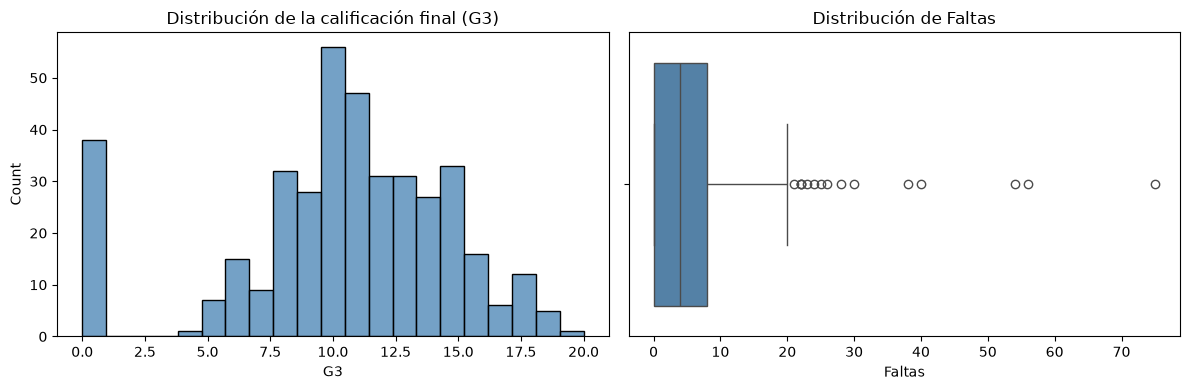

Estudiantes con G3 = 0: 38
Estudiantes con G2 = 0: 13
Faltas: máximo = 75 | percentil 95 = 18.299999999999955


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(datos["G3"], bins=21, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de la calificación final (G3)")
ax[0].set_xlabel("G3")

sns.boxplot(x=datos["Faltas"], ax=ax[1], color="steelblue")
ax[1].set_title("Distribución de Faltas")

plt.tight_layout()
plt.show()

print("Estudiantes con G3 = 0:", (datos["G3"] == 0).sum())
print("Estudiantes con G2 = 0:", (datos["G2"] == 0).sum())
print("Faltas: máximo =", datos["Faltas"].max(), "| percentil 95 =", datos["Faltas"].quantile(0.95))

38 estudiantes (casi el 10 %) tienen calificación final de 0. Ese grupo no forma parte de la campana
central y corresponde muy probablemente a estudiantes que abandonaron el curso, no a estudiantes que
respondieron mal el examen. De hecho, solo 13 de ellos tenían un 0 en `G2`, lo que confirma que el 0
final es un evento de deserción y no la continuación de una trayectoria de bajo desempeño.

`Faltas` muestra una cola derecha larga: el percentil 95 está en 16 faltas pero el máximo es 75.

## 4. Preparación y limpieza de los datos

### 4.1 Codificación de variables cualitativas

Las tres variables cualitativas son binarias, así que se codifican con **una sola columna 0/1** como se referenció en clase. El significado de cada codificación queda:

- `Escuela`: 1 = MS, 0 = GP 
- `Sexo`: 1 = M, 0 = F 
- `Internet`: 1 = sí tiene acceso, 0 = no 

In [6]:
df = datos.copy()
df["Escuela"] = (df["Escuela"] == "MS").astype(int)
df["Sexo"] = (df["Sexo"] == "M").astype(int)
df["Internet"] = (df["Internet"] == "yes").astype(int)

df.head()

,Escuela,Sexo,Edad,HorasDeEstudio,Reprobadas,Internet,Faltas,G1,G2,G3
0,0,0,18,2,0,0,6,5,6,6
1,0,0,17,2,0,1,4,5,5,6
2,0,0,15,2,3,1,10,7,8,10
3,0,0,15,3,0,1,2,15,14,15
4,0,0,16,2,0,0,4,6,10,10


### 4.2 Decisión sobre los valores atípicos

Se identificaron dos tipos de valores extremos y en ambos casos se decidió **conservarlos**:

- **Los 38 estudiantes con `G3 = 0`.** Eliminarlos mejoraría artificialmente las métricas del modelo,
  pero cambiaría la pregunta que se está respondiendo: el modelo dejaría de predecir "la calificación
  final de un estudiante" para predecir "la calificación final de un estudiante que no abandonó el curso". Simplemente se hace esa aclaración para tomar en cuenta el error que se obtendría de esos casos.
- **Las faltas extremas (hasta 75).** Son valores altos pero perfectamente posibles y consistentes con
  el resto del registro del estudiante, no errores de captura. A falta de contexto y habiendo eliminado el error de los alumnos que abandonaron, se conservan.

No se aplicó ninguna transformación a la variable objetivo ni se recortaron valores, para mantener el
modelo interpretable en la escala original de 0 a 20.

### 4.3 Partición entrenamiento / prueba

Se separan los datos **antes** de escalar y de seleccionar variables, por las razones de fuga de datos
explicadas en la metodología.

In [7]:
X = df.drop(columns="G3")
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (316, 9) | Prueba: (79, 9)


### 4.4 Escalamiento

Se estandarizan todas las variables explicativas (media 0, desviación estándar 1). Esto no cambia el
ajuste de una regresión lineal, pero permite **comparar directamente la magnitud de los coeficientes**
para juzgar la importancia relativa de cada variable.

El `StandardScaler` se ajusta **solo con `X_train`** y luego se aplica a ambos conjuntos.

In [8]:
escalador = StandardScaler().fit(X_train)

X_train_s = pd.DataFrame(escalador.transform(X_train), columns=X.columns)
X_test_s = pd.DataFrame(escalador.transform(X_test), columns=X.columns)

X_train_s.describe().T[["mean", "std"]].round(3)

,mean,std
Escuela,-0.0,1.002
Sexo,-0.0,1.002
Edad,-0.0,1.002
HorasDeEstudio,0.0,1.002
Reprobadas,-0.0,1.002
Internet,-0.0,1.002
Faltas,-0.0,1.002
G1,-0.0,1.002
G2,-0.0,1.002


## 5. Análisis de relaciones entre variables

### 5.1 Matriz de correlación

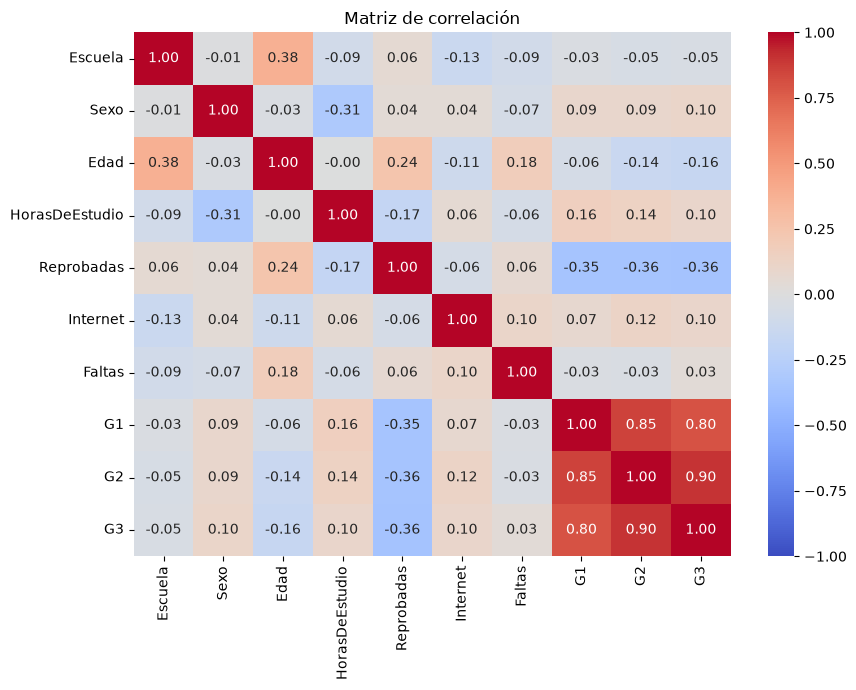

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [10]:
df.corr()["G3"].drop("G3").sort_values(ascending=False).round(3)

G2                0.905
G1                0.801
Sexo              0.103
Internet          0.098
HorasDeEstudio    0.098
Faltas            0.034
Escuela          -0.045
Edad             -0.162
Reprobadas       -0.360
Name: G3, dtype: float64

**Relación con la variable objetivo.** Las correlaciones con `G3` se separan claramente en dos
grupos:

- `G2` (0.90) y `G1` (0.80) tienen una relación lineal muy fuerte con la calificación final. Esto es
  esperable dado que es el mismo curso.
- `Reprobadas` (−0.36) tiene una relación moderada y negativa, coherente con el sentido común: haber
  reprobado materias antes anticipa un peor desempeño.
- El resto (`Edad` −0.16, `Sexo` 0.10, `Internet` 0.10, `HorasDeEstudio` 0.10, `Faltas` 0.03,
  `Escuela` −0.05) tienen correlaciones muy débiles. Incluso es de destacar que Faltas casi no tiene un impacto significativo.

**Redundancia entre explicativas.** La correlación entre `G1` y `G2` es de **0.85**, la más alta de la
matriz. Hay que tenerla presente al interpretar sus coeficientes, pero no es lo bastante severa como para justificar descartar una de las dos variables más informativas del conjunto.

## 6. Selección de características

**Método utilizado:** *selección hacia adelante rápida*. Las nueve variables se ordenan por su
correlación absoluta con `G3` y se construye una secuencia de modelos anidados: $M_1$ con la primera
del ranking, $M_2$ con las dos primeras, y así hasta $M_9$ con todas. Solo se ajustan 9 modelos, frente
a los 511 que exigiría probar todos los subconjuntos posibles.

**Criterio de comparación:** el RSS de entrenamiento **no sirve para elegir entre estos modelos**,
porque el modelo con todas las variables siempre tendrá el RSS más bajo y el $R^2$ más alto. Como esas
métricas se miden sobre los datos de entrenamiento, no reflejan el error de prueba. Por eso el error se
estima de forma **directa mediante validación cruzada** (5 particiones sobre el conjunto de
entrenamiento): se predice cada observación cuando queda fuera de su partición, y con ese RSS se
calcula el error estándar residual

$$\text{RSE} = \sqrt{\frac{\text{RSS}}{n - p - 1}}$$

que estima la desviación estándar del error, es decir el tamaño típico de la equivocación del modelo.

**Regla de paro:** en cada paso se agrega la siguiente variable del ranking solo si el RSE de
validación cruzada mejora; en cuanto deja de mejorar, el proceso se detiene.

Todo el proceso se ejecuta **únicamente sobre el conjunto de entrenamiento**.

In [11]:
# y_train conserva el índice original y X_train_s se reindexó al escalar,
# por lo que hay que alinearlos antes de correlacionar.
y_train_r = y_train.reset_index(drop=True)
ranking = X_train_s.corrwith(y_train_r).abs().sort_values(ascending=False)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n = len(y_train_r)
filas = []

for k in range(1, len(ranking) + 1):
    vs = ranking.index[:k].tolist()
    mod = LinearRegression().fit(X_train_s[vs], y_train_r)
    rss = ((y_train_r - mod.predict(X_train_s[vs])) ** 2).sum()

    # Predicción de cada observación cuando queda fuera de su partición.
    oof = cross_val_predict(LinearRegression(), X_train_s[vs], y_train_r, cv=kf)
    rss_cv = ((y_train_r - oof) ** 2).sum()

    filas.append({"k": k, "Variable agregada": vs[-1], "RSS": rss,
                  "RSE_CV": np.sqrt(rss_cv / (n - k - 1))})

modelos = pd.DataFrame(filas)

# Regla de paro: agregar la siguiente variable solo mientras el RSE de CV mejore.
k_opt = 1
for k in range(2, len(ranking) + 1):
    if modelos.loc[k - 1, "RSE_CV"] < modelos.loc[k_opt - 1, "RSE_CV"]:
        k_opt = k
    else:
        break

variables_sel = ranking.index[:k_opt].tolist()

print("Modelo seleccionado: k =", k_opt)
print("Variables seleccionadas:", variables_sel)
print("Variables descartadas:", [v for v in X.columns if v not in variables_sel])
modelos.round(3)

Modelo seleccionado: k = 2
Variables seleccionadas: ['G2', 'G1']
Variables descartadas: ['Escuela', 'Sexo', 'Edad', 'HorasDeEstudio', 'Reprobadas', 'Internet', 'Faltas']


,k,Variable agregada,RSS,RSE_CV
0,1,G2,1240.256,1.992
1,2,G1,1213.235,1.977
2,3,Reprobadas,1206.304,1.979
3,4,Edad,1200.209,1.984
4,5,Sexo,1191.969,1.993
5,6,Internet,1190.442,1.997
6,7,HorasDeEstudio,1184.246,2.007
7,8,Faltas,1129.794,1.964
8,9,Escuela,1124.327,1.965


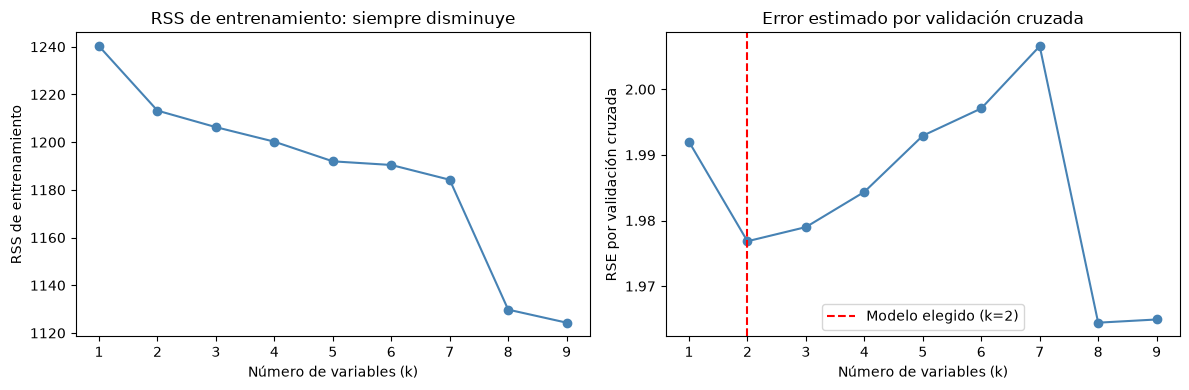

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(modelos["k"], modelos["RSS"], marker="o", color="steelblue")
ax[0].set_xlabel("Número de variables (k)")
ax[0].set_ylabel("RSS de entrenamiento")
ax[0].set_title("RSS de entrenamiento: siempre disminuye")

ax[1].plot(modelos["k"], modelos["RSE_CV"], marker="o", color="steelblue")
ax[1].axvline(k_opt, color="red", linestyle="--", label=f"Modelo elegido (k={k_opt})")
ax[1].set_xlabel("Número de variables (k)")
ax[1].set_ylabel("RSE por validación cruzada")
ax[1].set_title("Error estimado por validación cruzada")
ax[1].legend()

plt.tight_layout()
plt.show()

El ranking por correlación coloca a `G2` y `G1` en las dos primeras posiciones, muy por encima del
resto. La regla de paro se detiene en **k = 2**: el modelo seleccionado usa `G2` y `G1`.

Las dos gráficas muestran por qué no se puede elegir con el RSS. El **RSS de entrenamiento baja de
forma monótona**, de 1240 con una variable a 1124 con las nueve: si se eligiera por RSS, siempre
ganaría el modelo completo. El **RSE de validación cruzada**, en cambio, mejora solo en el primer paso
—de 1.992 a 1.977 al agregar `G1`— y a partir de ahí empeora.

**¿Vale la pena agregar más variables?** No. El punto más bajo de la curva de validación cruzada está
en k = 8 (1.964), pero es apenas un **0.6 % mejor** que el modelo de dos variables (1.977): seis
variables adicionales para reducir el error típico en poco más de una centésima de punto. En RSS de
entrenamiento esas variables sí reducen el error un 7.3 %, pero esa mejora no aparece en el error
validado, lo que indica que es sobreajuste. Se prefiere el modelo de dos variables, más simple de
interpretar y de recolectar.

## 7. Entrenamiento y evaluación del modelo

Se entrena una regresión lineal múltiple usando únicamente las variables seleccionadas en la sección anterior: G2 y G1.

In [13]:
modelo = LinearRegression().fit(X_train_s[variables_sel], y_train)

pred_train = modelo.predict(X_train_s[variables_sel])
pred_test = modelo.predict(X_test_s[variables_sel])

p = len(variables_sel)
filas = []

for nombre, y_real, y_pred in [("Entrenamiento", y_train, pred_train),
                               ("Prueba", y_test, pred_test)]:
    rss = ((y_real - y_pred) ** 2).sum()
    n_obs = len(y_real)
    r2 = r2_score(y_real, y_pred)
    filas.append({
        "Conjunto": nombre,
        "RSS": rss,
        "R²": r2,
        "R² ajustada": 1 - (1 - r2) * (n_obs - 1) / (n_obs - p - 1),
        "RSE": np.sqrt(rss / (n_obs - p - 1)),
    })

resultados = pd.DataFrame(filas).round(3)
resultados

,Conjunto,RSS,R²,R² ajustada,RSE
0,Entrenamiento,1213.235,0.825,0.824,1.969
1,Prueba,258.586,0.804,0.799,1.845


### 7.1 Interpretación de las métricas

El modelo explica el **82.5 % de la varianza** de la calificación final en entrenamiento y el
**80.4 % en prueba**. La $R^2$ ajustada, que corrige por el número de variables, es prácticamente
idéntica a la $R^2$ (0.824 y 0.799), señal de que las dos variables incluidas sí ganan su lugar. La
diferencia de apenas 2 puntos porcentuales entre ambos conjuntos indica que el modelo **generaliza
bien y no está sobreajustado**, algo esperable con solo dos variables. 

El **RSE de prueba es de 1.85 puntos**, es decir que el tamaño típico del error al predecir una
calificación final es de algo menos de dos puntos en la escala de 0 a 20. Llama la atención que sea
**menor** que el de entrenamiento (1.97), cuando lo habitual es lo contrario. La explicación está en la
composición de la partición: al conjunto de prueba le tocaron 5 estudiantes con calificación 0 de 79
(6.3 %), por debajo del 9.6 % que representan en el conjunto completo. Como esos casos son la principal
fuente de error, la partición de prueba resultó algo más fácil. No es evidencia de que el modelo
funcione mejor en datos nuevos, sino un recordatorio de que estas métricas dependen de una sola
partición aleatoria.

### 7.2 Coeficientes del modelo

Como las variables están estandarizadas, los coeficientes son comparables entre sí: cada uno indica
cuántos puntos cambia `G3` cuando esa variable aumenta una desviación estándar, manteniendo las demás
constantes.

In [14]:
coeficientes = pd.DataFrame({
    "Variable": variables_sel,
    "Coeficiente": modelo.coef_,
}).sort_values("Coeficiente", key=abs, ascending=False).round(3)

print("Intercepto:", round(modelo.intercept_, 3))
coeficientes

Intercepto: 10.364


,Variable,Coeficiente
0,G2,3.770
1,G1,0.561


`G2` domina el modelo por un margen amplio (coeficiente ≈ 3.77): un aumento de una desviación estándar
en la calificación del segundo periodo se asocia con casi 3.8 puntos más en la final. Le sigue `G1`
(≈ 0.56), muy por debajo pese a que su correlación individual con `G3` era de 0.80. La razón es la
colinealidad detectada en la sección 5: `G1` y `G2` comparten la mayor parte de su información, y una
vez que el modelo conoce `G2`, `G1` casi no agrega nada nuevo.

El modelo final es entonces muy simple: predice la calificación final a partir de las dos
calificaciones parciales, con un intercepto de 10.36 que corresponde a la calificación esperada de un
estudiante promedio.

### 7.3 Análisis visual del ajuste

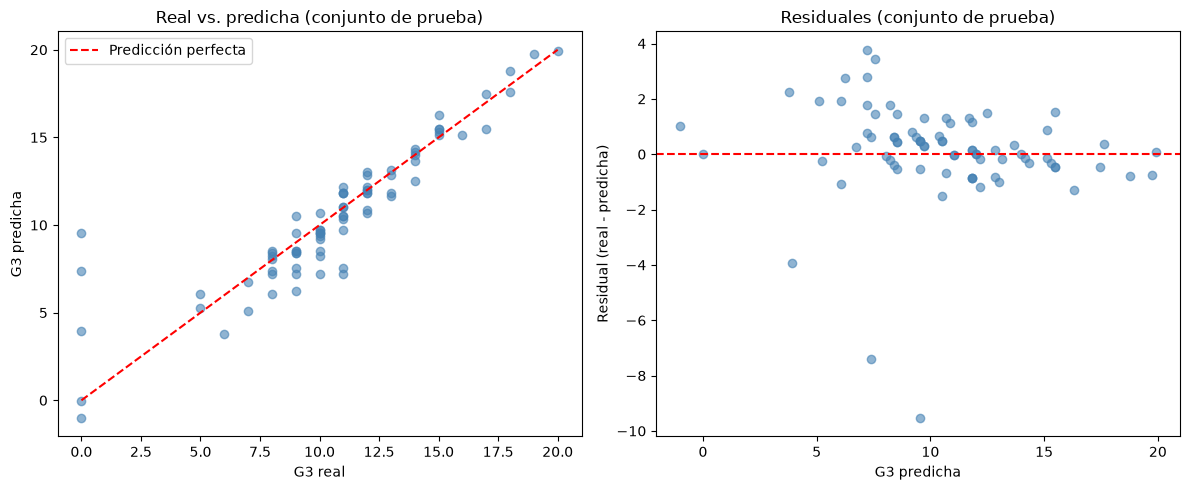

In [15]:
residuales = y_test - pred_test

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(y_test, pred_test, alpha=0.6, color="steelblue")
ax[0].plot([0, 20], [0, 20], "r--", label="Predicción perfecta")
ax[0].set_xlabel("G3 real")
ax[0].set_ylabel("G3 predicha")
ax[0].set_title("Real vs. predicha (conjunto de prueba)")
ax[0].legend()

ax[1].scatter(pred_test, residuales, alpha=0.6, color="steelblue")
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_xlabel("G3 predicha")
ax[1].set_ylabel("Residual (real - predicha)")
ax[1].set_title("Residuales (conjunto de prueba)")

plt.tight_layout()
plt.show()

Ambas gráficas apuntan a lo mismo. En **real vs. predicha**, los puntos siguen de cerca la diagonal:
fuera de los casos de deserción, los errores quedan entre −1.5 y 3.8 puntos. La excepción es la franja
sobre `G3 = 0`, 5 estudiantes a los que el modelo predice entre −1.0 y 9.5. En **residuales**, esos
mismos casos son el grupo muy por debajo del cero, con un error máximo de −9.5; el resto se reparte de
forma aleatoria alrededor del cero, sin patrón, lo que respalda el supuesto de linealidad.

**¿Son coherentes estos resultados?** Sí, y confirman lo anticipado en la sección 4.2: el error se
concentra en los estudiantes que desertaron. Es lo esperado, porque la deserción responde a factores
ausentes del conjunto de datos —situación económica, salud, cambio de escuela— y no a un mal
desempeño previo que el modelo pudiera detectar. Lo que **no** era esperado es que dos predicciones
resulten negativas (−1.0 y −0.02), imposibles en una escala de 0 a 20: la regresión lineal desconoce
las cotas de la variable objetivo.

## 8. Reflexión y conclusiones

**Se cumplió el objetivo general.** Se construyó un modelo de regresión lineal múltiple que predice la
calificación final con **R² de 0.80 y RSE de 1.85 puntos en datos de prueba no vistos**, usando solo
dos variables: `G2` y `G1`.

**Sobre la preparación de los datos.** La decisión de mayor impacto fue **conservar los 38 estudiantes
con calificación 0**: eliminarlos habría dado métricas más vistosas, pero el modelo respondería una
pregunta distinta a la planteada. La codificación de las variables cualitativas y el escalamiento
fueron requisitos para poder usarlas y para comparar coeficientes entre escalas distintas.

**Sobre la selección de características.** Más variables no significan mejor modelo: se descartaron 7
de 9 y el modelo generaliza igual de bien. El RSS de entrenamiento no sirve como criterio porque
premia siempre al modelo más grande; las variables adicionales lo reducen un 7.3 % pero no mejoran el
RSE de validación cruzada, señal de que esa ganancia es sobreajuste.

**Limitaciones.**

1. Depende por completo de `G1` y `G2`, así que solo es utilizable cuando ya transcurrieron dos
   terceras partes del curso.
2. No predice la deserción, su principal fuente de error, y llega a dar predicciones negativas.
3. Las variables de contexto social (`Escuela`, `Internet`, `HorasDeEstudio`) estaban muy
   desbalanceadas.

**Mejoras futuras.** Personalmente me gustaría usar el dataset completo para analizar el cambio en el peso de las variables, y ver si alguna otra combinación puede ser de utilidad en el estudio. También creo que es importante hacer más entrenamientos y más pruebas, para ver cómo irá cambiando los resultados, y analizar tendencias. Otra cosa podría ser el uso de otras materias, para ver si las calificaciones afectan por maeria o por estudiante, y ampliar el caso del estudio.

*Se usó la Inteligencia Artificial Generativa para apoyo en la codificación y recomendación de desiciones.

## 9. Referencias bibliográficas
- UCI Machine Learning Repository. (2018). Uci.Edu. https://archive.ics.uci.edu/dataset/320/student+performance
